# 🏠 Predicción del precio de viviendas — Modelado y evaluación

Este notebook continúa la fase de preparación de datos, centrándose en el entrenamiento, evaluación y mejora de modelos de machine learning para la predicción del precio de viviendas.

Se abordan las siguientes etapas:
- Entrenamiento de modelos base
- Evaluación comparativa
- Mejora mediante ensembles
- Interpretabilidad del modelo
- Feature engineering
- Tratamiento de outliers
- Análisis no supervisado

Dataset: Kaggle — House Prices: Advanced Regression Techniques

In [1]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor

from sklearn.inspection import PartialDependenceDisplay
from sklearn.ensemble import IsolationForest

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture

import shap
shap.initjs()

## Carga de datos procesados

Se utiliza el dataset generado en la fase de preparación (`houses_prep.csv`).

In [2]:
data = pd.read_csv('data/houses_prep.csv', index_col=0)
data.shape

(1460, 303)

## División de datos

Se separa el conjunto en entrenamiento y test (33%) para evaluar la capacidad de generalización.

In [3]:
X = data.drop(columns='SalePrice').copy()
y = data['SalePrice'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=0
)

## Evaluación de modelos

Se define una función auxiliar para comparar modelos utilizando:
- R² (train, validación, test)
- MAE (train, test)

In [4]:
results = pd.DataFrame(columns=[
    'Modelo','R2 Train','R2 Val','R2 Test','MAE Train','MAE Test'
]).set_index('Modelo')


def show_results(name, model, X_train, y_train, X_test, y_test, is_log=False):
    train_r2 = model.score(X_train, y_train)
    val_r2 = cross_val_score(model, X_train, y_train, cv=5).mean()
    test_r2 = model.score(X_test, y_test)

    f = np.exp if is_log else lambda y: y

    train_mae = mean_absolute_error(f(y_train), f(model.predict(X_train)))
    test_mae = mean_absolute_error(f(y_test), f(model.predict(X_test)))

    results.loc[name] = (train_r2, val_r2, test_r2, train_mae, test_mae)

    print(f"{name}")
    print(f"R2 -> Train: {train_r2:.3f} | Val: {val_r2:.3f} | Test: {test_r2:.3f}")
    print(f"MAE -> Train: {train_mae:.2f} | Test: {test_mae:.2f}\n")

## Modelos base

Se entrenan modelos iniciales para establecer una línea base:
- Regresión Ridge
- Árbol de decisión

In [5]:
parameters = {'alpha': np.logspace(-4, 4, 9)}
search = GridSearchCV(Ridge(), parameters, cv=5)
search.fit(X_train, y_train)

ridge = search.best_estimator_
show_results("Ridge", ridge, X_train, y_train, X_test, y_test)

Ridge
R2 -> Train: 0.921 | Val: 0.854 | Test: 0.776
MAE -> Train: 13310.46 | Test: 18043.08



### 🔍 Optimización de Hiperparámetros - Decision Tree

Se realiza una búsqueda de los mejores hiperparámetros utilizando `GridSearchCV` para optimizar el rendimiento del modelo `DecisionTreeRegressor`.

**Parámetros ajustados:**
- `max_depth`: Controla la profundidad máxima del árbol (complejidad del modelo)
- `min_samples_split`: Número mínimo de muestras necesarias para dividir un nodo

> ⚠️ Nota: El parámetro `max_depth` debe ser un número entero. Usar directamente `np.linspace` genera valores decimales (`float`), lo que provoca un error en el modelo.

In [6]:
parameters = {
    'max_depth': list(range(1, 16)),
    'min_samples_split': [2, 4, 6, 8, 10]
}

search = GridSearchCV(
    DecisionTreeRegressor(random_state=0),
    parameters,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
search.fit(X_train, y_train)

tree = search.best_estimator_
show_results("Decision Tree", tree, X_train, y_train, X_test, y_test)

Decision Tree
R2 -> Train: 0.994 | Val: 0.723 | Test: 0.717
MAE -> Train: 3428.38 | Test: 26219.18



## Mejora con Random Forest

Se introduce un modelo ensemble para reducir varianza y mejorar robustez.

In [7]:
parameters = {'max_depth':[1,5,10,15,20]}
search = GridSearchCV(RandomForestRegressor(random_state=0), parameters, cv=5)
search.fit(X_train, y_train)

rforest = search.best_estimator_
show_results("Random Forest", rforest, X_train, y_train, X_test, y_test)

Random Forest
R2 -> Train: 0.979 | Val: 0.854 | Test: 0.855
MAE -> Train: 6685.50 | Test: 17283.36



## Variables más relevantes

Se identifican las variables más influyentes según el modelo.

In [8]:
relevant_feat = X_train.columns[
    np.argsort(rforest.feature_importances_)[-20:]
].tolist()

relevant_feat

['MoSold',
 'OverallCond',
 'OpenPorchSF',
 'FullBath',
 'YearRemodAdd',
 'LotFrontage',
 'BsmtQual_Ex',
 'GarageYrBlt',
 'BsmtUnfSF',
 '2ndFlrSF',
 'YearBuilt',
 'LotArea',
 'MasVnrArea',
 '1stFlrSF',
 'GarageCars',
 'GarageArea',
 'BsmtFinSF1',
 'TotalBsmtSF',
 'GrLivArea',
 'OverallQual']

## Interpretabilidad del modelo

Se analiza el impacto de variables clave en las predicciones.

### 📊 Partial Dependence Plots (PDP)

Se utilizan Partial Dependence Plots para analizar cómo cada variable afecta la predicción del modelo de Random Forest.

Este método permite visualizar el impacto marginal de una o dos variables sobre la variable objetivo, manteniendo el resto de características constantes.

**Variables analizadas:**
- `OverallQual`: Calidad general del material y acabado
- `GrLivArea`: Área habitable sobre el suelo
- Interacción entre ambas variables

> ⚠️ Nota técnica: Es necesario convertir los datos a tipo `float`, ya que los PDP generan valores continuos y no son compatibles con columnas de tipo `int64` en pandas.

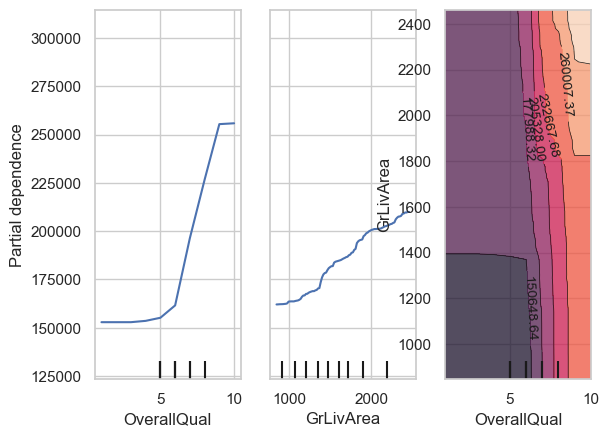

In [9]:
from sklearn.inspection import PartialDependenceDisplay

# Asegurar formato correcto
X_train = X_train.astype(float)

features = [
    'OverallQual',
    'GrLivArea',
    ('OverallQual', 'GrLivArea')
]

PartialDependenceDisplay.from_estimator(
    rforest,
    X_train,
    features,
    method='brute'
)

## Interpretabilidad local (SHAP)

Se analiza cómo contribuyen las variables a predicciones individuales.

In [10]:
explainer = shap.TreeExplainer(rforest)

sample = X_test.iloc[0]
shap_values = explainer.shap_values(sample)

shap.force_plot(explainer.expected_value, shap_values, sample)

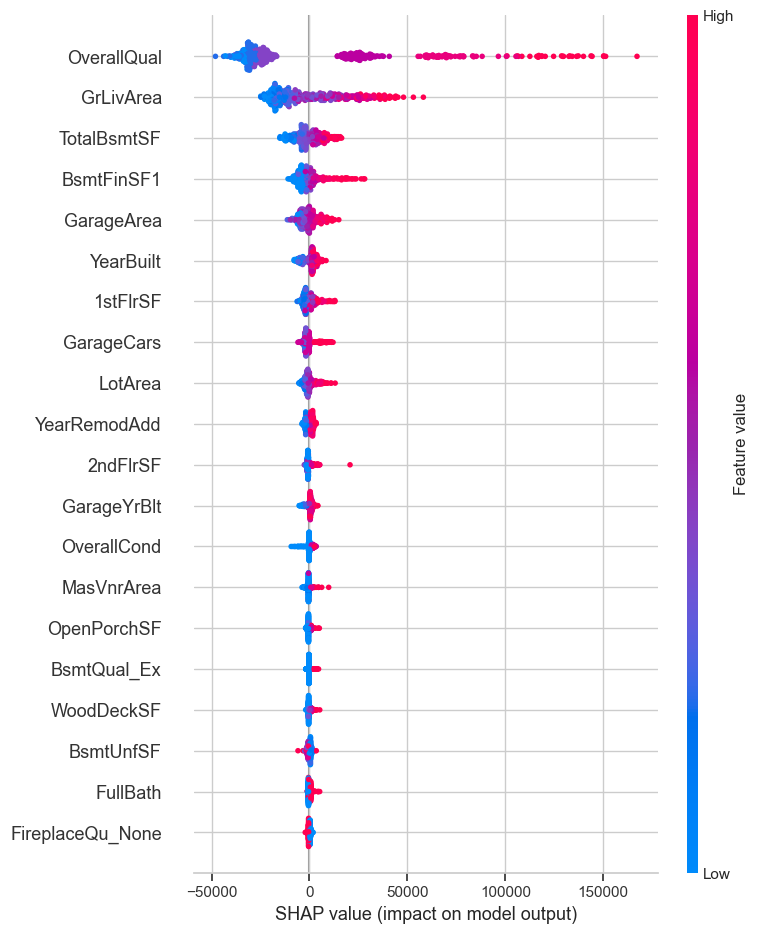

In [69]:
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

Las variables más influyentes según SHAP coinciden con las identificadas por el modelo (OverallQual, GrLivArea), lo que valida la coherencia del modelo.

## Modelo basado en distancia (KNN)

Se evalúa el impacto de la estandarización en algoritmos basados en distancia.

In [11]:
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

parameters = {
    'knn__n_neighbors': range(3, 30),
    'knn__weights': ('uniform', 'distance')
}

search = GridSearchCV(pipe_knn, parameters, cv=5)
search.fit(X_train, y_train)

knn = search.best_estimator_
show_results("KNN", knn, X_train, y_train, X_test, y_test)

KNN
R2 -> Train: 1.000 | Val: 0.732 | Test: 0.713
MAE -> Train: 0.00 | Test: 25104.41



El modelo KNN presenta un error de entrenamiento nulo debido a su naturaleza basada en instancias (instance-based learning), lo que permite una predicción casi perfecta en el conjunto de entrenamiento. Sin embargo, el rendimiento en test (MAE ≈ 25k) refleja su capacidad real de generalización.

El error de entrenamiento es 0 porque KNN puede memorizar los datos cuando k es bajo. 
Esto no indica buen rendimiento, sino sobreajuste.

## Feature engineering

Se aplican transformaciones para mejorar la capacidad predictiva:
- Logaritmo en variables sesgadas
- Transformación cíclica en variables temporales

In [12]:
data_feat = data.copy()

data_feat['SalePrice'] = np.log(data_feat['SalePrice'])
data_feat['GrLivArea'] = np.log(data_feat['GrLivArea'])
data_feat['MoSold'] = np.sin(2*np.pi*data_feat['MoSold']/12-4)

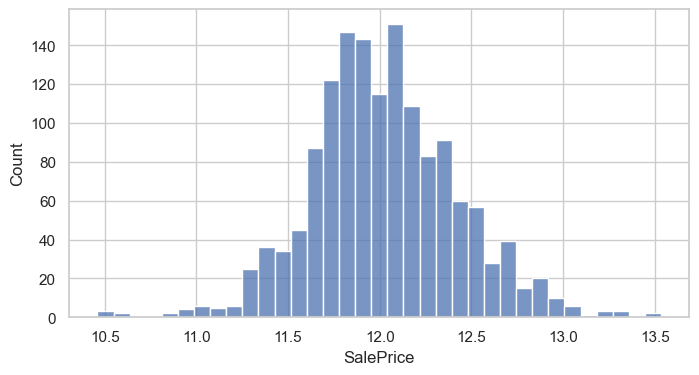

In [71]:
plt.figure(figsize=(8,4))
sns.histplot(x=data_feat['SalePrice'], fill=True, linewidth=1);

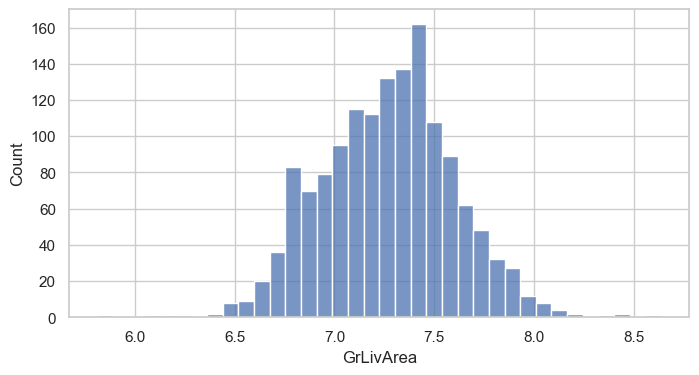

In [72]:
plt.figure(figsize=(8,4))
sns.histplot(x=data_feat['GrLivArea'], fill=True, linewidth=1);

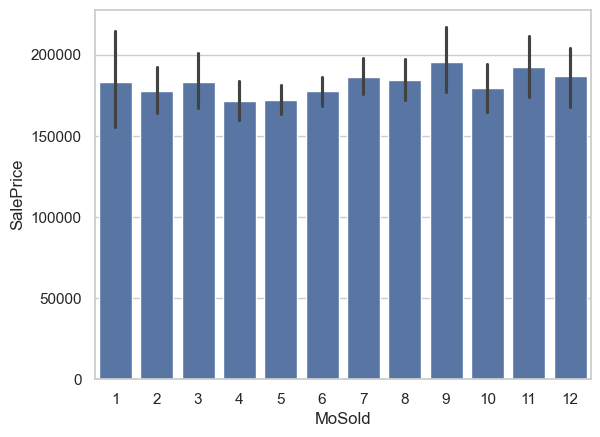

In [76]:
data.sort_values(by='MoSold', inplace=True)
ax = sns.barplot(x=data['MoSold'].astype('str'), y=data['SalePrice']);

## Tratamiento de outliers

Se identifican y eliminan observaciones anómalas.

In [13]:
iforest = IsolationForest(contamination=0.005)
iforest.fit(X_train)

mask = iforest.predict(X_train) == 1

X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

## Reducción de dimensionalidad (PCA)

Se resetean los índices antes de aplicar PCA para asegurar la correcta alineación entre las componentes principales y la variable objetivo.
Se reentrenan los modelos utilizando únicamente las variables más relevantes.

In [18]:
X = data.drop('SalePrice', axis=1).reset_index(drop=True)
y = data['SalePrice'].reset_index(drop=True)

pca = PCA(n_components=2)
data_pc = pca.fit_transform(X)

data_pc = pd.DataFrame(data_pc, columns=['PC1', 'PC2'])
data_pc['SalePrice'] = y

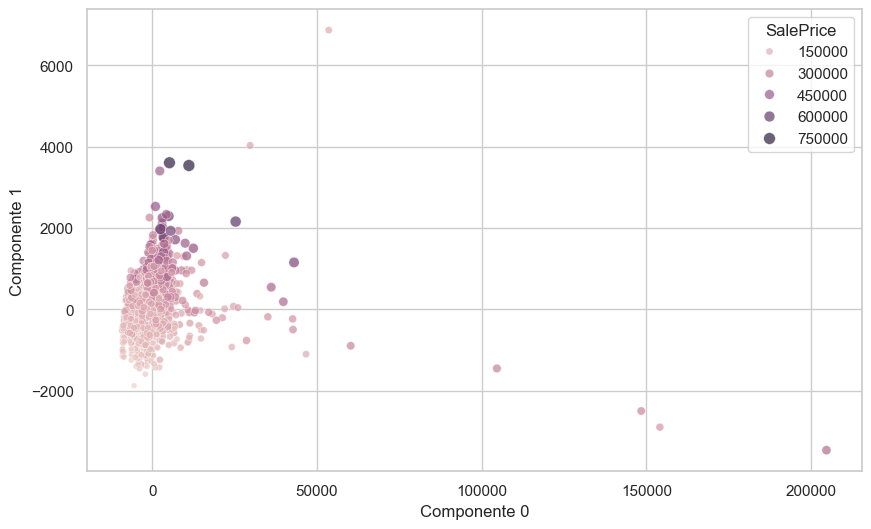

In [27]:
plt.figure(figsize=(10,6))
plt.xlabel("Componente 0")
plt.ylabel("Componente 1")
sns.scatterplot(
    data=data_pc,
    x='PC1',
    y='PC2',
    hue='SalePrice',
    size='SalePrice',
    alpha=0.7
);

## Visualización con t-SNE

### 📉 Visualización con t-SNE

Se utiliza t-SNE para proyectar los datos en 2 dimensiones, preservando relaciones locales entre observaciones.

Esto permite identificar posibles agrupaciones y analizar cómo se distribuye la variable objetivo (*SalePrice*) en el espacio reducido.

In [35]:
pipe_tsne = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, random_state=0))
])

data_vis = pipe_tsne.fit_transform(X)

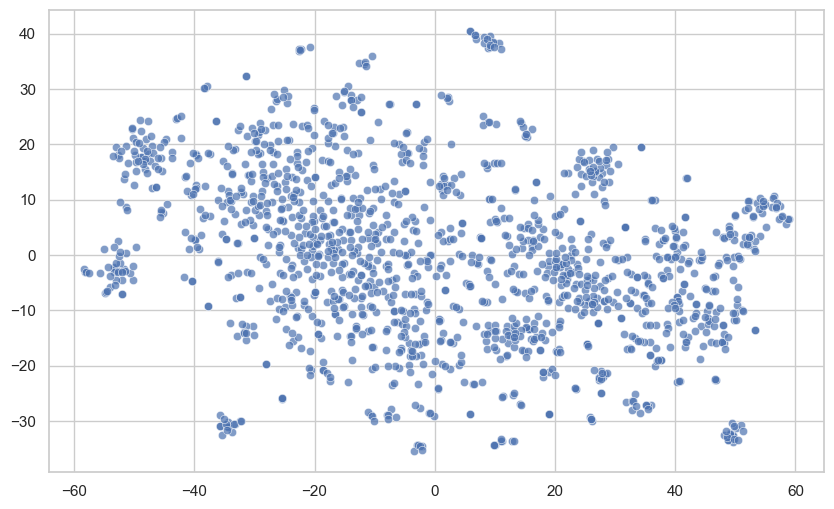

In [36]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=data_vis[:,0], y=data_vis[:,1], cmap=plt.cm.Spectral, alpha=0.7);

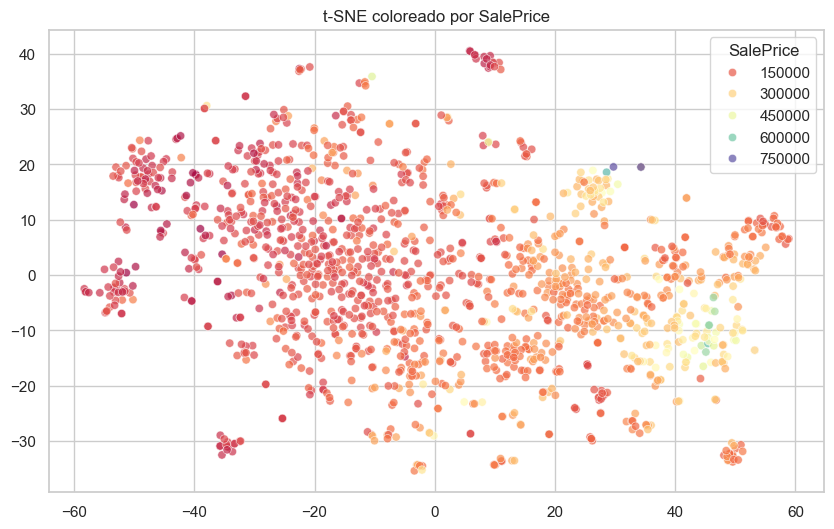

In [37]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=data_vis[:,0], 
    y=data_vis[:,1], 
    hue=y, 
    palette='Spectral', 
    alpha=0.7
)

plt.title("t-SNE coloreado por SalePrice")
plt.show()

⚠️ Nota: t-SNE no preserva distancias globales, por lo que los clusters deben interpretarse con cautela. Es una técnica principalmente visual.

<Axes: >

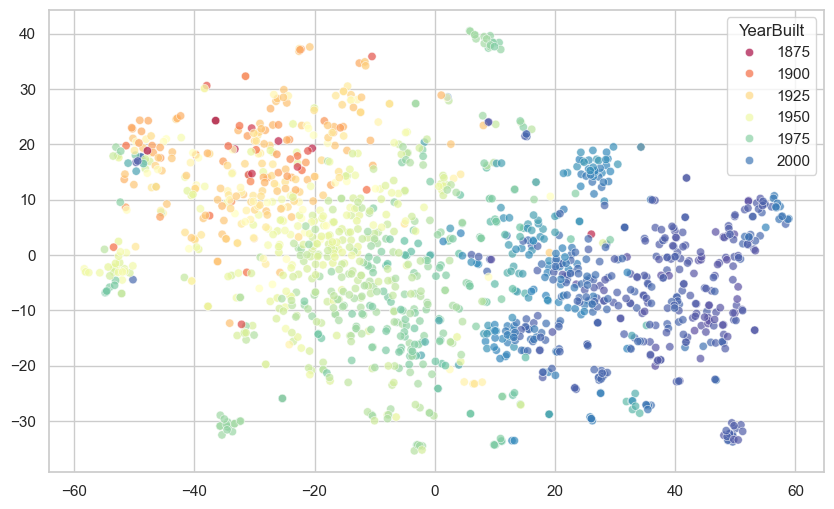

In [42]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=data_vis[:,0], 
    y=data_vis[:,1], 
    hue=X['YearBuilt'],
    palette='Spectral', 
    alpha=0.7
)

### ⚖️ Comparación: PCA vs t-SNE

- PCA captura varianza global (lineal)
- t-SNE captura estructura local (no lineal)

En este caso, t-SNE muestra agrupaciones más definidas, lo que sugiere relaciones no lineales en los datos.

## Clustering (Gaussian Mixture)

In [53]:
pipe_gm = Pipeline([
    ('scaler', StandardScaler()),
    ('gm', GaussianMixture(n_components=2))
])

cluster = pipe_gm.fit_predict(X)

In [54]:
X.loc[:,'cluster'] = cluster

In [56]:
X.groupby('cluster').mean()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
cluster,,,,,,,,,,,,,,,,,,,,,
0,73.006834,10681.936219,6.673121,5.438497,1989.121868,1993.527335,140.560364,535.198178,41.873576,610.070615,...,0.002278,0.136674,0.000000,0.829157,0.051253,0.000000,0.001139,0.010251,0.799544,0.137813
1,65.121993,10267.747423,5.233677,5.781787,1944.333333,1971.798969,46.630584,305.515464,53.603093,502.627148,...,0.005155,0.003436,0.005155,0.926117,0.096220,0.006873,0.018900,0.018900,0.852234,0.006873


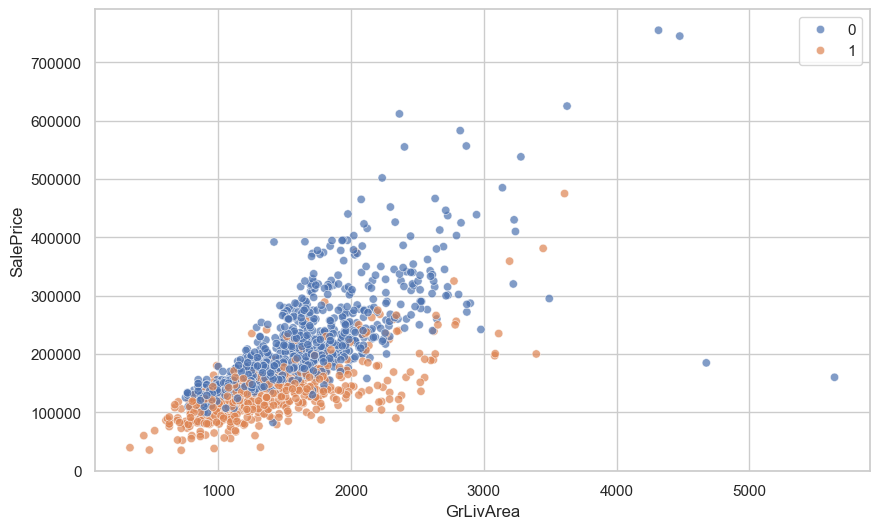

In [59]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=X['GrLivArea'], y=y, hue=cluster, alpha=0.7);

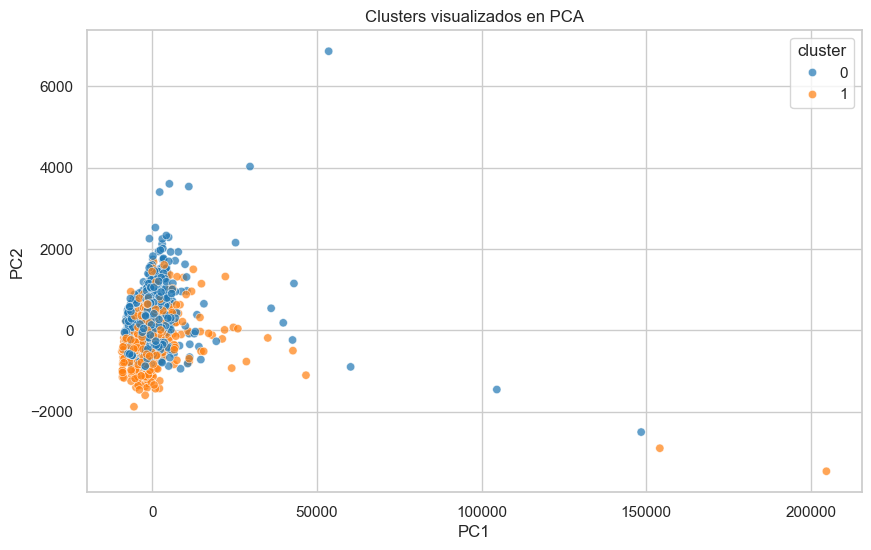

In [67]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=data_pc['PC1'], 
    y=data_pc['PC2'], 
    hue=X['cluster'], 
    palette='tab10',
    alpha=0.7
)

plt.title("Clusters visualizados en PCA")
plt.show()

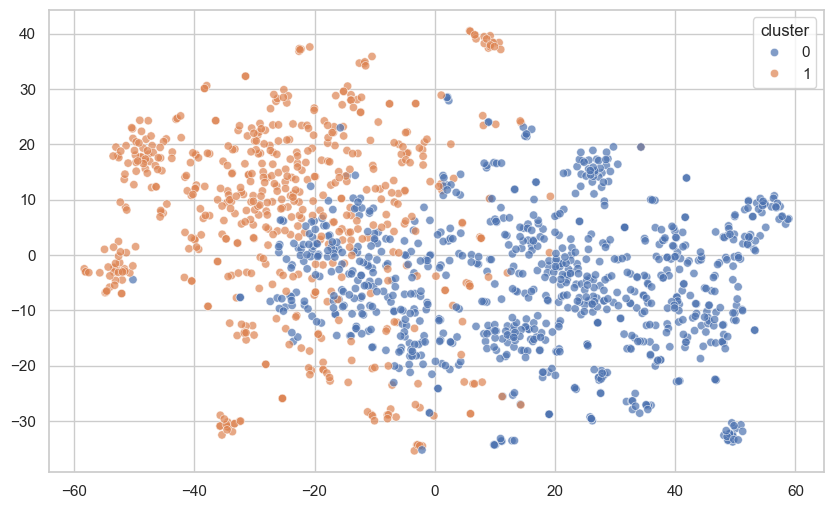

In [68]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=data_vis[:,0], y=data_vis[:,1], hue=X['cluster'], alpha=0.7);

El clustering permite identificar segmentos de viviendas con características similares. 
Sin embargo, no se observa una separación clara en términos de precio, lo que sugiere que la variable objetivo depende de múltiples factores combinados.

## Conclusiones

- Random Forest ofrece el mejor equilibrio entre sesgo y varianza
- Feature engineering mejora significativamente el rendimiento
- La eliminación de outliers incrementa la capacidad de generalización
- Variables como `OverallQual` y `GrLivArea` dominan la predicción
- Técnicas como PCA y t-SNE permiten entender mejor la estructura del dataset

Este flujo reproduce un pipeline completo de machine learning aplicado a un problema real.

## 🚀 Próximos pasos

- Optimización más avanzada (RandomizedSearch / Bayesian Optimization)
- Modelos más complejos (XGBoost, LightGBM)
- Validación más robusta (K-Fold repetido)
- Feature selection automatizada